In [27]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

In [28]:
image_dir = 'data/examples/offroad/deepscene/images'
mask_dir = 'data/examples/offroad/deepscene/masks_multi_class'

In [29]:
image_paths = [image_dir + '/' +  x for x in os.listdir(image_dir)]
mask_paths = [mask_dir + '/' + x for x in os.listdir(mask_dir)]
image_paths.sort()
mask_paths.sort()

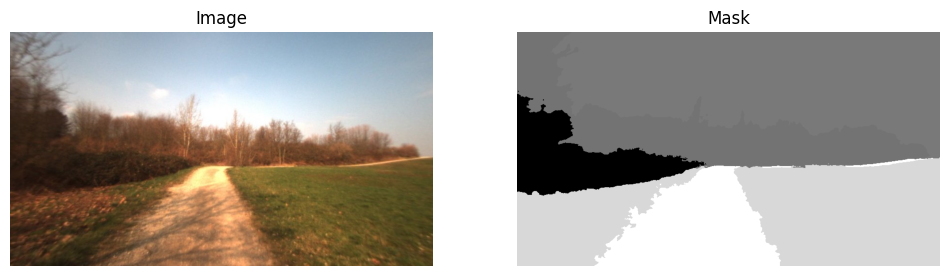

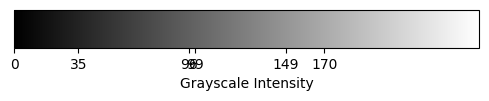

In [56]:
def show_image_and_mask(index: int):
    # Read the first image and mask
    image = cv2.imread(image_paths[0])
    mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

    # Convert the image from BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image and mask
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')


    figure = get_color_bar()

    plt.show()

show_image_and_mask(0)

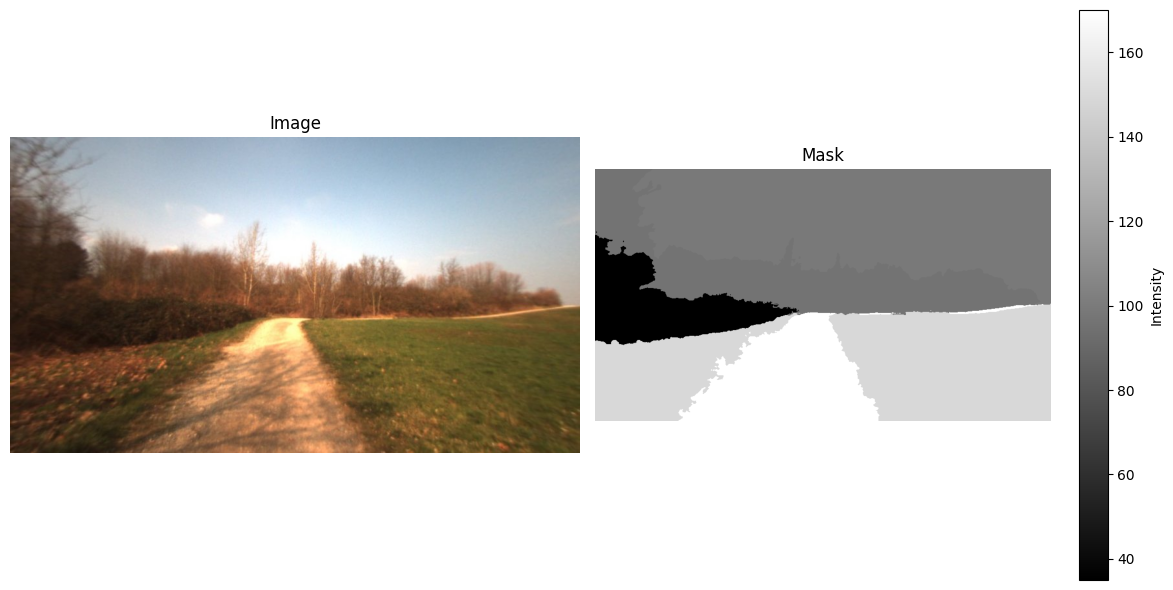

In [59]:
import cv2
import matplotlib.pyplot as plt
import mplcursors

def show_image_and_mask(index: int):
    # Read the image and mask
    image = cv2.imread(image_paths[index])
    mask = cv2.imread(mask_paths[index], cv2.IMREAD_GRAYSCALE)

    # Convert the image from BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image and mask
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Image')
    axes[0].axis('off')

    mask_plot = axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')

    # Add colorbar
    cbar = plt.colorbar(mask_plot, ax=axes[1], orientation='vertical', label='Intensity')

    # Use mplcursors to show pixel values on hover
    cursor = mplcursors.cursor(mask_plot, hover=True)

    @cursor.connect("add")
    def on_add(sel):
        x, y = sel.target.index
        value = mask[y, x]
        sel.annotation.set_text(f'Intensity: {value}')

    plt.tight_layout()
    plt.show()

# Assuming image_paths and mask_paths are defined
show_image_and_mask(0)

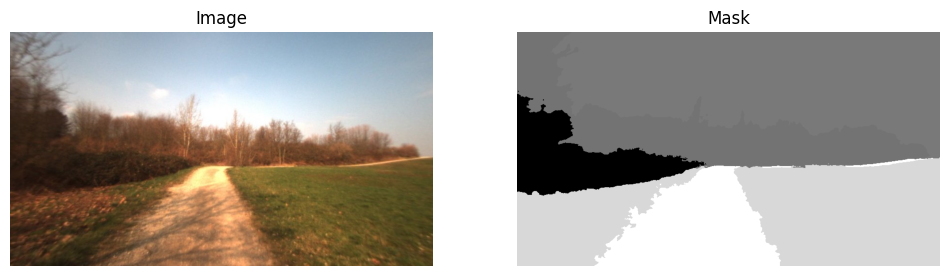

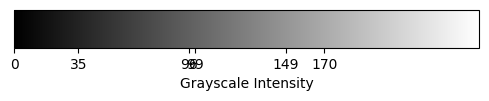

In [57]:
proceed = 'y'
i = 0
while proceed != 'n':
    show_image_and_mask(i)
    proceed = input("continue?")
    i+=1

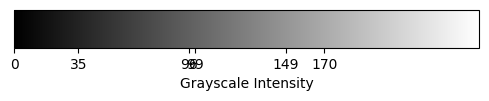

In [ ]:

{0, 35, 96, 99, 149, 170}
def get_color_bar():

    fig, ax = plt.subplots(figsize=(6, 1))
    fig.subplots_adjust(bottom=0.5)

    # Create a colormap and normalize object
    cmap = plt.cm.gray
    norm = plt.Normalize(vmin=0, vmax=255)

    # Create a colorbar
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax, orientation='horizontal')
    cb.set_label('Grayscale Intensity')

    # Add x ticks for the specified intensities
    cb.set_ticks([0, 35, 96, 99, 149, 170])
    cb.set_ticklabels(['0', '35', '96', '99', '149', '170'])

    return fig


figure = get_color_bar()
plt.show()